In [1]:
# %matplotlib widget

In [2]:
import os
import json
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [3]:
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
result_save_path = current_dir
log_relative_path = 'data/training_logs/Mid/sim2real_kps_Mid_contact_Time_100s_Max_Epochs_1000_Optimized_Factor_Sum_Scale_Damp_Mass_Ratio_simultaneous_start_with_1_0.01_lr/log.json'
training_log_path = os.path.join(parent_dir, log_relative_path)
OPTIMIZE_SUBJECT = ["Youngs_Modulus", "Applied_Force", "Force_Amplification", "Damping_Amplification", "Factor_Sum_Scale", "Damp_Mass_Ratio"]
OPTIMIZED_METHOD = [None, "simultaneous", "alternating"]
LOSS_TYPE = ["total_loss", "avg_loss", "avg_loss_per_point"]
OPTPARAMS = [OPTIMIZE_SUBJECT[4], OPTIMIZE_SUBJECT[5]]
num_colors = 5

cmap = plt.get_cmap("viridis")  # tab10, tab20, viridis, plasma...

COLORMAP = cmap(np.linspace(0.1, 0.9, num_colors))

# Function libs

## utils

In [4]:
def load_training_log(log_path, opt_param=OPTPARAMS):
    with open(log_path, 'r') as f:
        data = json.load(f)
    optimized_parameters = []
    for i in opt_param:
        if i == "Youngs_Modulus":
            optimized_parameters.append(np.array(data["Youngs_Modulus_log"]))  
            continue
        optimized_parameters.append(np.array(data[i]))
         
    total_loss = np.array(data["total_loss"])
    avg_loss = np.array(data["avg_loss"])
    avg_loss_per_point = np.array(data["avg_loss_per_point"])
    
    return optimized_parameters, total_loss, avg_loss, avg_loss_per_point

In [5]:
def relative_loss_visualization(loss, 
                                relative_loss_reference=0.5,
                                relative_loss_clamp_switch = False,
                                relative_loss_clamp_thresh = 1.0,
                                scatter_switch=False,
                                save_flag=False,
                                save_name="relative_loss_change",
                                save_path=None):
    initial_relative_loss = 0
    relative_loss_lis = [initial_relative_loss]
    for i in range(1, len(loss)):
        relative_loss = ((loss[i] - loss[i-1]) / max(abs(loss[i-1]), 1e-8)) * 100
        relative_loss_lis.append(relative_loss)
    relative_loss_lis = np.array(relative_loss_lis)
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(relative_loss_lis))
    ax.plot(x, relative_loss_lis, color='b', label='Relative Loss changes')
    ax.axhline(y=relative_loss_reference, color='r', linestyle='--', label=f'Reference: {relative_loss_reference}%')
    ax.axhline(y=-relative_loss_reference, color='r', linestyle='--')
    if scatter_switch:
        ax.scatter(x, relative_loss_lis, color='b', s=50, marker='x')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(f'Relative Loss Change (%)')
    ax.set_xlim(0, len(relative_loss_lis))
    if relative_loss_clamp_switch:
        clamp_thresh = np.abs(relative_loss_clamp_thresh)
        ax.set_ylim(-clamp_thresh, clamp_thresh)
    if save_flag:
        if save_path is None:
            print('Save path not specified, using default.')
            fig.savefig(f"{save_name}.pdf", dpi=300, bbox_inches='tight')
        else:
            fig.savefig(f"{save_path}/{save_name}.pdf", dpi=300, bbox_inches='tight')

In [6]:
def loss_visualization(total_loss, 
                       avg_loss, 
                       avg_loss_per_point,
                       loss_type_lis=["total loss"],
                       loss_clamp_switch=False,
                       loss_plot_type="line",
                       scatter_switch=False,
                       save_flag=False,
                       save_name="loss",
                       save_path=None):
    x = np.arange(len(avg_loss))  # iteration / step
    # Right axis: total_loss
    for loss_type in loss_type_lis:
        fig, ax = plt.subplots(figsize=(10, 5))
        if loss_type == "total_loss":
            save_name = "total_loss"
            if loss_plot_type == "line":
                ax.plot(x, total_loss, color='r', linewidth=2, label='Total Loss')
                y_scale = 1.05
                y_min = 0.
            elif loss_plot_type == "semilogy":
                ax.semilogy(x, total_loss, color='r', linewidth=2, label='Total Loss')
                y_scale = 5.
                y_min = 1.e-2
            if scatter_switch:
                ax.scatter(x, total_loss, color='r', s=30, marker='x', label='Total Loss (step)')
            ax.set_ylabel('Total Loss')
            ax.tick_params(axis='y')
            y_up_bd = max(total_loss) * y_scale
            if loss_clamp_switch:
                y_up_bd = min(y_up_bd, 10.0)
            ax.set_ylim(y_min, y_up_bd)
        elif loss_type == "avg_loss":
            save_name = "avg_loss"
            if loss_plot_type == "line":
                ax.plot(x, avg_loss, color='r', linewidth=2, label='Average Loss')
                y_scale = 1.05
                y_min = 0.
            elif loss_plot_type == "semilogy":
                ax.semilogy(x, avg_loss, color='r', linewidth=2, label='Average Loss')
                y_scale = 5.
                y_min = 1.e-2
            if scatter_switch:
                ax.scatter(x, avg_loss, color='r', s=10, marker='x')
            ax.set_ylabel('Average Loss')
            ax.tick_params(axis='y')
            y_up_bd = max(avg_loss_per_point) * y_scale
            if loss_clamp_switch:
                y_up_bd = min(y_up_bd, 10.0)
            ax.set_ylim(y_min, y_up_bd)
        elif loss_type == "avg_loss_per_point":
            save_name = "avg_loss_per_point"
            if loss_plot_type == "line":
                ax.plot(x, avg_loss_per_point, color='r', linewidth=2, label='Average Loss Per Point')
                y_scale = 1.05
                y_min = 0.
            elif loss_plot_type == "semilogy":
                ax.semilogy(x, avg_loss_per_point, color='r', linewidth=2, label='Average Loss Per Point')
                y_scale = 5.
                y_min = 1.e-2
            if scatter_switch:
                ax.scatter(x, avg_loss_per_point, color='r', s=10, marker='x')
            ax.set_ylabel('Average Loss Per Point')
            ax.tick_params(axis='y')
            y_up_bd = max(avg_loss_per_point) * y_scale
            if loss_clamp_switch:
                y_up_bd = min(y_up_bd, 10.0)
            ax.set_ylim(y_min, y_up_bd)

        ax.set_xlabel('Epoch')
        ax.set_xlim(0, len(avg_loss)-0.9)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.legend()
        if save_flag:
            if save_path is None:
                print('Save path not specified, using default.')
                fig.savefig(f"{save_name}.pdf", dpi=300, bbox_inches='tight')
            else:
                fig.savefig(f"{save_path}/{save_name}.pdf", dpi=300, bbox_inches='tight')
        plt.show()

In [7]:
def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = x_limits[1] - x_limits[0]
    y_range = y_limits[1] - y_limits[0]
    z_range = z_limits[1] - z_limits[0]

    max_range = max(x_range, y_range, z_range)

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    ax.set_xlim3d([x_middle - max_range/2, x_middle + max_range/2])
    ax.set_ylim3d([y_middle - max_range/2, y_middle + max_range/2])
    ax.set_zlim3d([z_middle - max_range/2, z_middle + max_range/2])

## main funcs

In [8]:
def loss_param_visualization(log_path,
                             target_path = None,
                             target_param = None,
                             opt_param=OPTPARAMS,
                             optimizing_method = None,
                             loss_type_lis=["total_loss"],
                             loss_clamp_switch = False,
                             relative_loss_reference = 0.5,
                             relative_loss_clamp_switch = False,
                             relative_loss_clamp_thresh = 1.0,
                             loss_plot_type="line",
                             scatter_switch=False,
                             save_flag=False,
                             save_path=None):
    
    optimized_parameters, total_loss, avg_loss, avg_loss_per_point = load_training_log(log_path, opt_param=opt_param)
    param_max = max([max(param) for param in optimized_parameters])
    x = np.arange(len(avg_loss))  # iteration / step

    # Left axis: optimized_parameters
    if optimizing_method is None or optimizing_method == "simultaneous":
        for i in range(len(opt_param)):
            fig, ax = plt.subplots(figsize=(10, 5))
            if opt_param[i] == "Youngs_Modulus":
                data_label = f'{opt_param[i]} log'
            else:
                data_label = f'{opt_param[i]}'
            if len(avg_loss) != len(optimized_parameters[i]):
                opt_params = optimized_parameters[i][:-1]
            else:
                opt_params = optimized_parameters[i]
            ax.plot(x, opt_params, color=COLORMAP[i], label=data_label)
            if scatter_switch:
                ax.scatter(x, opt_params, color=COLORMAP[i], s=50, marker='x')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(f'{opt_param[i]}')
            ax.set_xlim(0, len(avg_loss))
            # ax.set_ylim(0, max(optimized_parameters[i]) * 1.05)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.legend()
            if save_flag:
                if save_path is None:
                    print('Save path not specified, using default.')
                    fig.savefig(f"{opt_param[i]}.pdf", dpi=300, bbox_inches='tight')
                else:
                    fig.savefig(f"{save_path}/{opt_param[i]}.pdf", dpi=300, bbox_inches='tight')
            plt.show()
    elif optimizing_method == "alternating":
        for i in range(len(opt_param)):
            fig, ax = plt.subplots(figsize=(10, 5))
            if opt_param[i] == "Youngs_Modulus":
                data_label = f'{opt_param[i]} log'
            else:
                data_label = f'{opt_param[i]}'
            if len(avg_loss) != len(optimized_parameters[i]):
                opt_params = optimized_parameters[i][:-1]
            else:
                opt_params = optimized_parameters[i]
            ax.step(x, opt_params, where='post', linewidth=2, color=COLORMAP[i], label=data_label)
            if scatter_switch:
                ax.scatter(x, opt_params, color=COLORMAP[i], s=10, marker='x')
            if target_param is not None:
                ax.axhline(y=target_param[i], color='black', linewidth=2, linestyle='--', label=f'Start {data_label}')
                
            ax.set_xlabel('Epoch')
            ax.set_ylabel(f'{opt_param[i]}')
            ax.set_xlim(0, len(avg_loss)-0.9)
            # ax.set_ylim(top = max(optimized_parameters[i]) * 1.05)
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.legend()
            if save_flag:
                if save_path is None:
                    print('Save path not specified, using default.')
                    fig.savefig(f"{opt_param[i]}.pdf", dpi=300, bbox_inches='tight')
                else:
                    fig.savefig(f"{save_path}/{opt_param[i]}.pdf", dpi=300, bbox_inches='tight')
            plt.show()
    
    loss_visualization(total_loss, 
                       avg_loss,
                       avg_loss_per_point,
                       loss_type_lis=loss_type_lis,
                       loss_clamp_switch=loss_clamp_switch,
                       loss_plot_type=loss_plot_type,
                       scatter_switch=scatter_switch,
                       save_flag=save_flag,
                       save_path=save_path)

    relative_loss_visualization(avg_loss, 
                                relative_loss_reference=relative_loss_reference,
                                relative_loss_clamp_switch=relative_loss_clamp_switch,
                                relative_loss_clamp_thresh=relative_loss_clamp_thresh,
                                scatter_switch=scatter_switch,
                                save_flag=save_flag,
                                save_path=save_path)

# Visualization

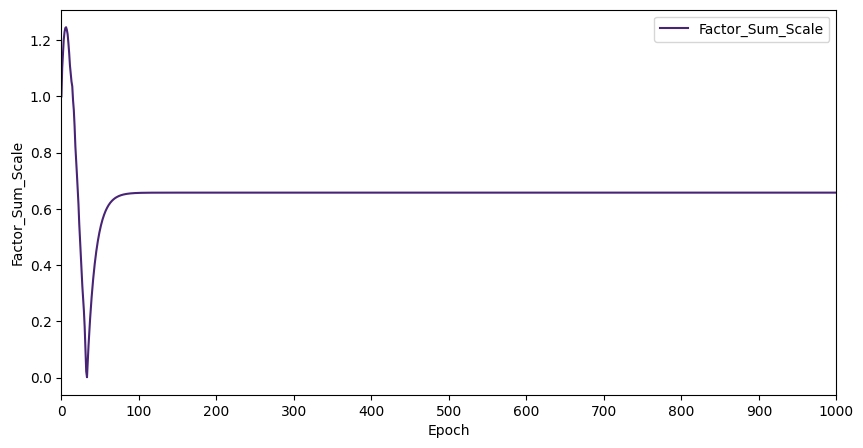

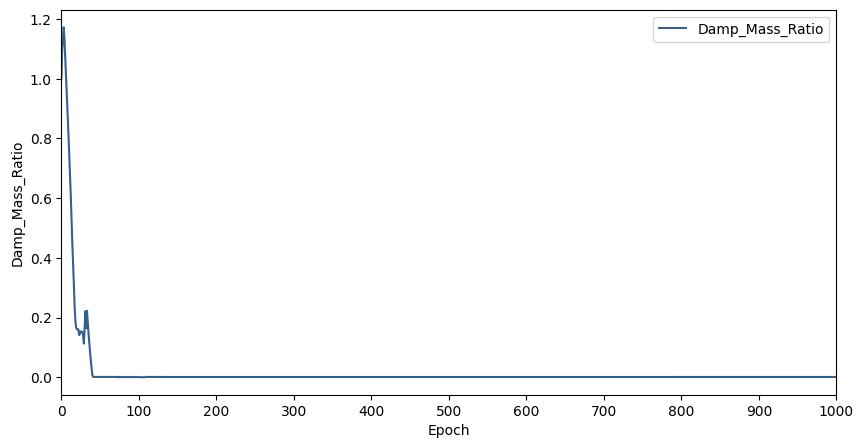

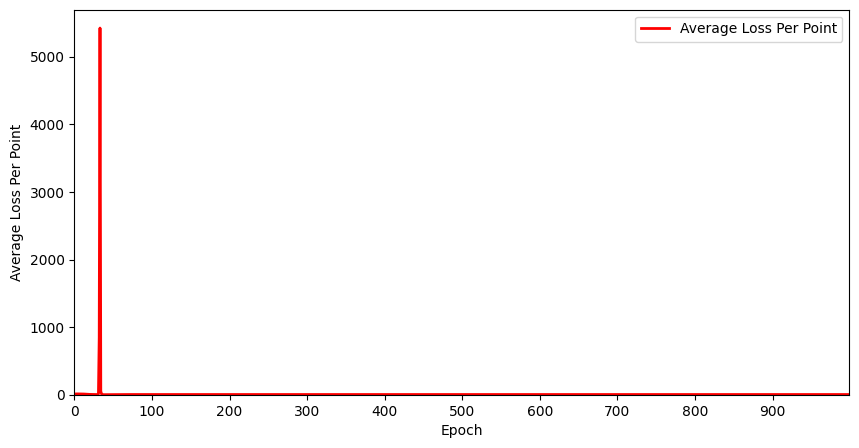

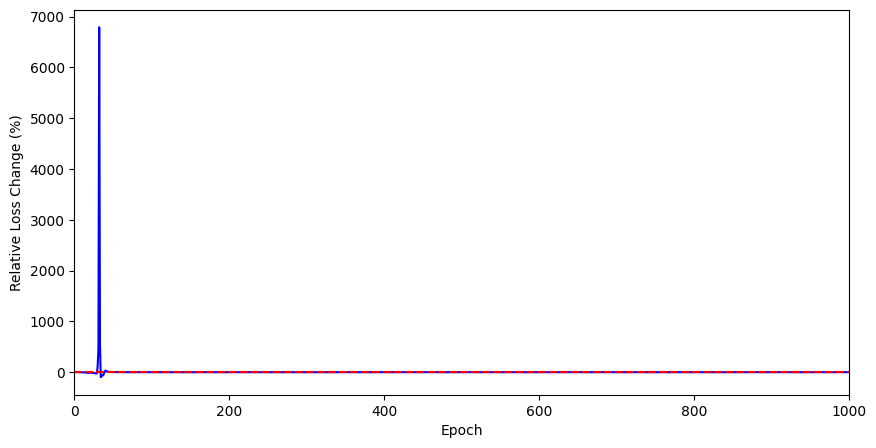

In [9]:
loss_param_visualization(training_log_path, 
                         target_param = [1.0, np.log(9500.e3)],
                         opt_param=OPTPARAMS,
                         optimizing_method=OPTIMIZED_METHOD[1], # 0 for None, 1 for simultaneous, 2 for alternating
                         loss_type_lis=[LOSS_TYPE[2]], # 0 for total_loss, 1 for avg_loss, 2 for avg_loss_per_point
                         loss_clamp_switch = False,
                         relative_loss_reference = 0.5,
                         relative_loss_clamp_switch = False,
                         relative_loss_clamp_thresh = 0.25,
                         loss_plot_type="line",
                         scatter_switch=False,
                         save_flag=False,
                         save_path=result_save_path)